## Задача 1

Реализовать класс для работы с линейной регрессией

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class MyLinearRegression:
    """
    Parameters
    ----------
    regularization : {None, 'l1', 'l2', 'l1l2'}, default=None
        Какую регуляризацию добавить к модели. Если значение `None`, то без регуляризации.

    weight_calc : {'matrix', 'gd', 'sgd'}, default='matrix'
        Каким образом вычислять вектор весов: матрично ('matrix'), градиентным спуском ('gd') или стохастическим градиентным спуском ('sgd'). При этом, при 'l1' или 'l1l2' нельзя использовать параметр 'matrix'.

    Attributes
    ----------
    coefs_ : Вектор коэффициентов размера (p, 1), где p — количество признаков.
    intercept_ : Значение коэффициента, отвечающего за смещение
    """

    def __init__(self, regularization = None, weight_calc = 'matrix', lambda_1 = None, lambda_2 = None, batch_size = 20,
                 random_state = 42, alpha = 0.01, max_iter = 5000, early_stopping = 0.0001):
        if regularization not in [None, 'l1', 'l2', 'l1l2']:
            raise TypeError(f"Параметр regularization не может принимать значение '{regularization}'")
        if weight_calc not in ['matrix', 'gd', 'sgd']:
            raise TypeError(f"Параметр weight_calc не может принимать значение '{weight_calc}'")
        if regularization in ['l1', 'l1l2'] and lambda_1 is None:
            raise TypeError(f"Значение коэффициента регулризации l1 не задано")
        if regularization in ['l2', 'l1l2'] and lambda_2 is None:
            raise TypeError(f"Значение коэффициента регулризации l2 не задано")

        self.regularization = regularization
        self.weight_calc = weight_calc
        self.coefs_ = None
        self.intercept_ = None
        self.lambda_1 = lambda_1
        self.lambda_2 = lambda_2
        self.batch_size = batch_size
        self.random_state = random_state
        self.alpha = alpha
        self.max_iter = max_iter
        self.early_stopping = early_stopping
    
    def _initialization(self, X):

        np.random.seed(self.random_state)
        X_new = np.hstack((np.ones((X.shape[0], 1)), X))
        W = np.random.uniform(size = X_new.shape[1])
        return X_new, W

    def _get_gradient(self, X, Y, W):
        grad = 2 / X.shape[0] * X.T @ (X @ W - Y)
    
        if self.regularization == 'l1':
            grad[1:] += self.lambda_1 * np.sign(W[1:])
        elif self.regularization == 'l2':
            grad[1:] += 2 * self.lambda_2 * W[1:]
        elif self.regularization == 'l1l2':
            grad[1:] += self.lambda_1 * np.sign(W[1:]) + 2 * self.lambda_2 * W[1:]
        
        return grad
    
    def GD_regression(self, X, Y):

        X_new, W = self._initialization(X)
        for _ in range(self.max_iter):

            grad = self._get_gradient(X_new, Y, W)
            W_new = W - self.alpha * grad

            if np.linalg.norm(W_new - W) < self.early_stopping:
                return W[0], W[1:]
            
            W = W_new

        return W[0], W[1:]
    
    def SGD_regression(self, X, Y):

        X_new, W = self._initialization(X)
        n_samples = X.shape[0]

        for _ in range(self.max_iter):
            indices = np.random.permutation(n_samples)

            X_shuffled = X_new[indices]
            y_shuffled = Y[indices]

            for j in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[j:j + self.batch_size]
                y_batch = y_shuffled[j:j + self.batch_size]

                grad = self._get_gradient(X_batch, y_batch, W)

                W_new = W - self.alpha * grad

                if np.linalg.norm(W_new - W) < self.early_stopping:
                    return W[0], W[1:]
                
                W = W_new

        return W[0], W[1:]

    def fit(self, X: pd.DataFrame, y: pd.DataFrame):

        X = X.to_numpy()
        y = y.to_numpy()

        if self.weight_calc == 'matrix':

            if self.regularization in ['l1', 'l1l2']:
                raise ValueError("L1 и L1L2 регуляризация не поддерживаются для матричного решения")

            X_new = np.hstack((np.ones((X.shape[0], 1)), X))

            theta_full = np.linalg.inv(X_new.T @ X_new) @ X_new.T @ y

            self.intercept_ = theta_full[0]
            self.coefs_ = theta_full[1:]

        elif self.weight_calc == 'gd':
            theta_full = self.GD_regression(X, y)

            self.intercept_ = theta_full[0]
            self.coefs_ = theta_full[1:]
        
        else:
            theta_full = self.SGD_regression(X, y)

            self.intercept_ = theta_full[0]
            self.coefs_ = theta_full[1:]

    def predict(self, X: np.array, ss=True):
        return X @ np.array([self.intercept_, *self.coefs_])

    def score(self, X: np.array, y: np.array):
    
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        
        r2 = 1 - (ss_res / ss_tot)
        return r2

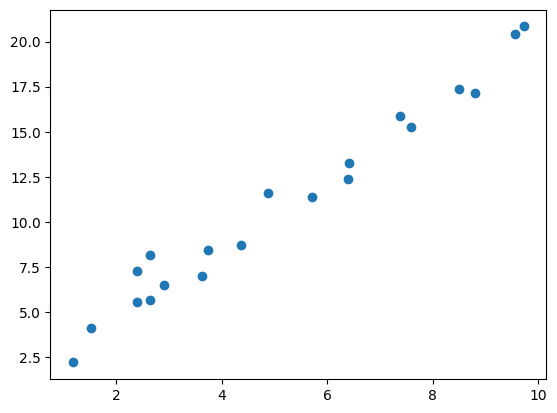

In [66]:
n_samples = 20
np.random.seed(42)

X = np.random.uniform(1, 10, (n_samples, 1))
Y = (2 * X + 1 + np.random.normal(0, 1, (n_samples, 1))).reshape(-1)

plt.scatter(X, Y)

In [67]:
linreg = MyLinearRegression()
linreg.fit(X, Y)
theta_0 = linreg.intercept_
theta = linreg.coefs_
print(linreg.intercept_, linreg.coefs_)

AttributeError: 'numpy.ndarray' object has no attribute 'to_numpy'

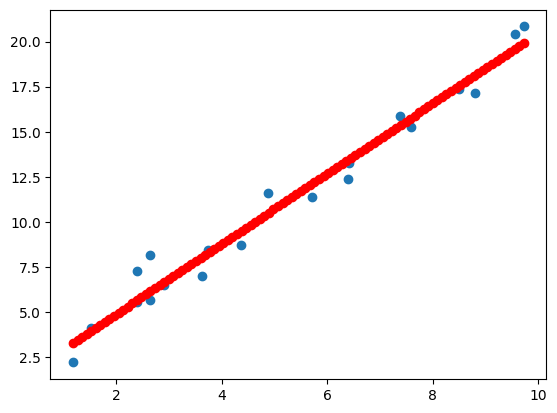

In [45]:
plt.scatter(X, Y)
x = np.linspace(np.min(X), np.max(X), 100).reshape(1, -1)
y1 = x*theta[0] + theta_0
plt.scatter(x, y1, color = 'red')

In [43]:
linreg = MyLinearRegression(weight_calc='gd')
linreg.fit(X, Y)
theta_0 = linreg.intercept_
theta = linreg.coefs_
print(linreg.intercept_, linreg.coefs_)

0.9977489009998943 (array([1.94618354]),)


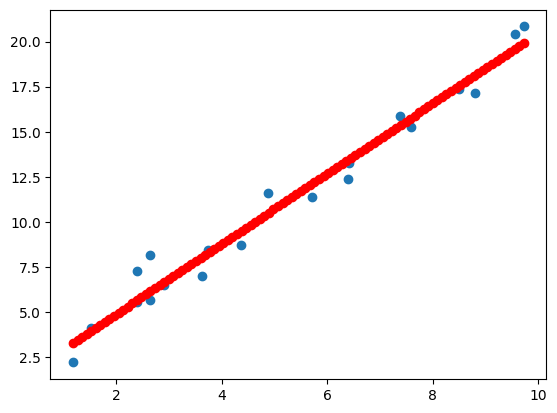

In [50]:
plt.scatter(X, Y)
x = np.linspace(np.min(X), np.max(X), 100).reshape(1, -1)
y2 = x*theta[0] + theta_0
plt.scatter(x, y2, color = 'red')

In [46]:
linreg = MyLinearRegression(weight_calc='sgd')
linreg.fit(X, Y)
theta_0 = linreg.intercept_
theta = linreg.coefs_
print(linreg.intercept_, linreg.coefs_)

0.9977489009998947 (array([1.94618354]),)


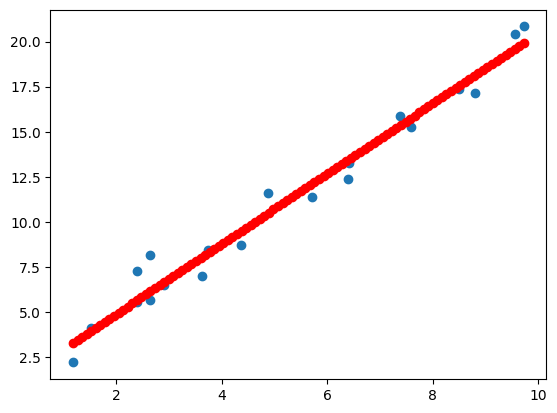

In [47]:
plt.scatter(X, Y)
x = np.linspace(np.min(X), np.max(X), 100).reshape(1, -1)
y3 = x*theta[0] + theta_0
plt.scatter(x, y3, color = 'red')

Используя датасет про автомобили (целевой признак — price), сравнить (качество, скорость обучения и предсказания, важность признаков) модели `MyLinearRegression` с различными гиперпараметрами, сделать выводы. На этом же датасете сравнить модель `MyLinearRegression` с библиотечной реализацией из `sklearn`, составить таблицу(ы) (графики) результатов сравнения (качество, скорость обучения и предсказания, важность признаков).

In [69]:
df = pd.read_csv('./data/data.csv')
df.head()

,model,engine_power,transmission,age_in_days,km,previous_owners,lat,lon,price
0,pop,69,manual,4474,56779,2,45.071079,7.46403,4490
1,lounge,69,manual,2708,160000,1,45.069679,7.70492,4500
2,lounge,69,automatic,3470,170000,2,45.514599,9.28434,4500
3,sport,69,manual,3288,132000,2,41.903221,12.49565,4700
4,sport,69,manual,3712,124490,2,45.532661,9.03892,4790


In [27]:
df.dtypes

model               object
engine_power         int64
transmission        object
age_in_days          int64
km                   int64
previous_owners      int64
lat                float64
lon                float64
price                int64
dtype: object

In [82]:
X = df.drop(columns = ['model', 'transmission', 'previous_owners', 'price'])
Y = df['price']
X = (X - X.mean(axis=0)) / X.std(axis=0)

In [83]:
linreg = MyLinearRegression(weight_calc='gd')
linreg.fit(X, Y)
theta_0 = linreg.intercept_
theta = linreg.coefs_
print(linreg.intercept_, linreg.coefs_)

5881.6552631578725 (array([   44.64602574, -1597.4552353 ,  -520.75320805,   236.48458077,
         278.2307991 ]),)


In [84]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X, Y)
print(linreg.intercept_, linreg.coef_)

5881.655263157894 [   44.64677489 -1597.46987967  -520.73825338   236.47867887
   278.22378334]


## Задача 2

[Соревнование на Kaggle](https://kaggle.com/competitions/yadro-regression-2025)